In [30]:
import numpy as np
import matplotlib.pyplot as plt

import tensor_cross_interpolation as tci
from convolution_as_MPO import construct_convolution_MPO

import importlib
importlib.reload(tci)

<module 'tensor_cross_interpolation' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Noisy/tensor_cross_interpolation.py'>

In [31]:
# define some helper functions
def contract_MPS(Ms):
    vals = np.squeeze(Ms[0])
    for M in Ms[1:]:
        vals = np.einsum('ia, ajb -> ijb', vals, M)
        vals = vals.reshape(-1, M.shape[-1])
    vals = vals.reshape(-1)
    return vals

def apply_MPO(MPO, MPS):
    Ms = []
    for W, M in zip(MPO, MPS):
        chilW, chirW, d, _ = W.shape
        chilM, _, chirM = M.shape
        Ms.append(np.einsum('abkj, cjd -> ackbd', W, M).reshape(chilW * chilM, d, chirW * chirM))
    return Ms

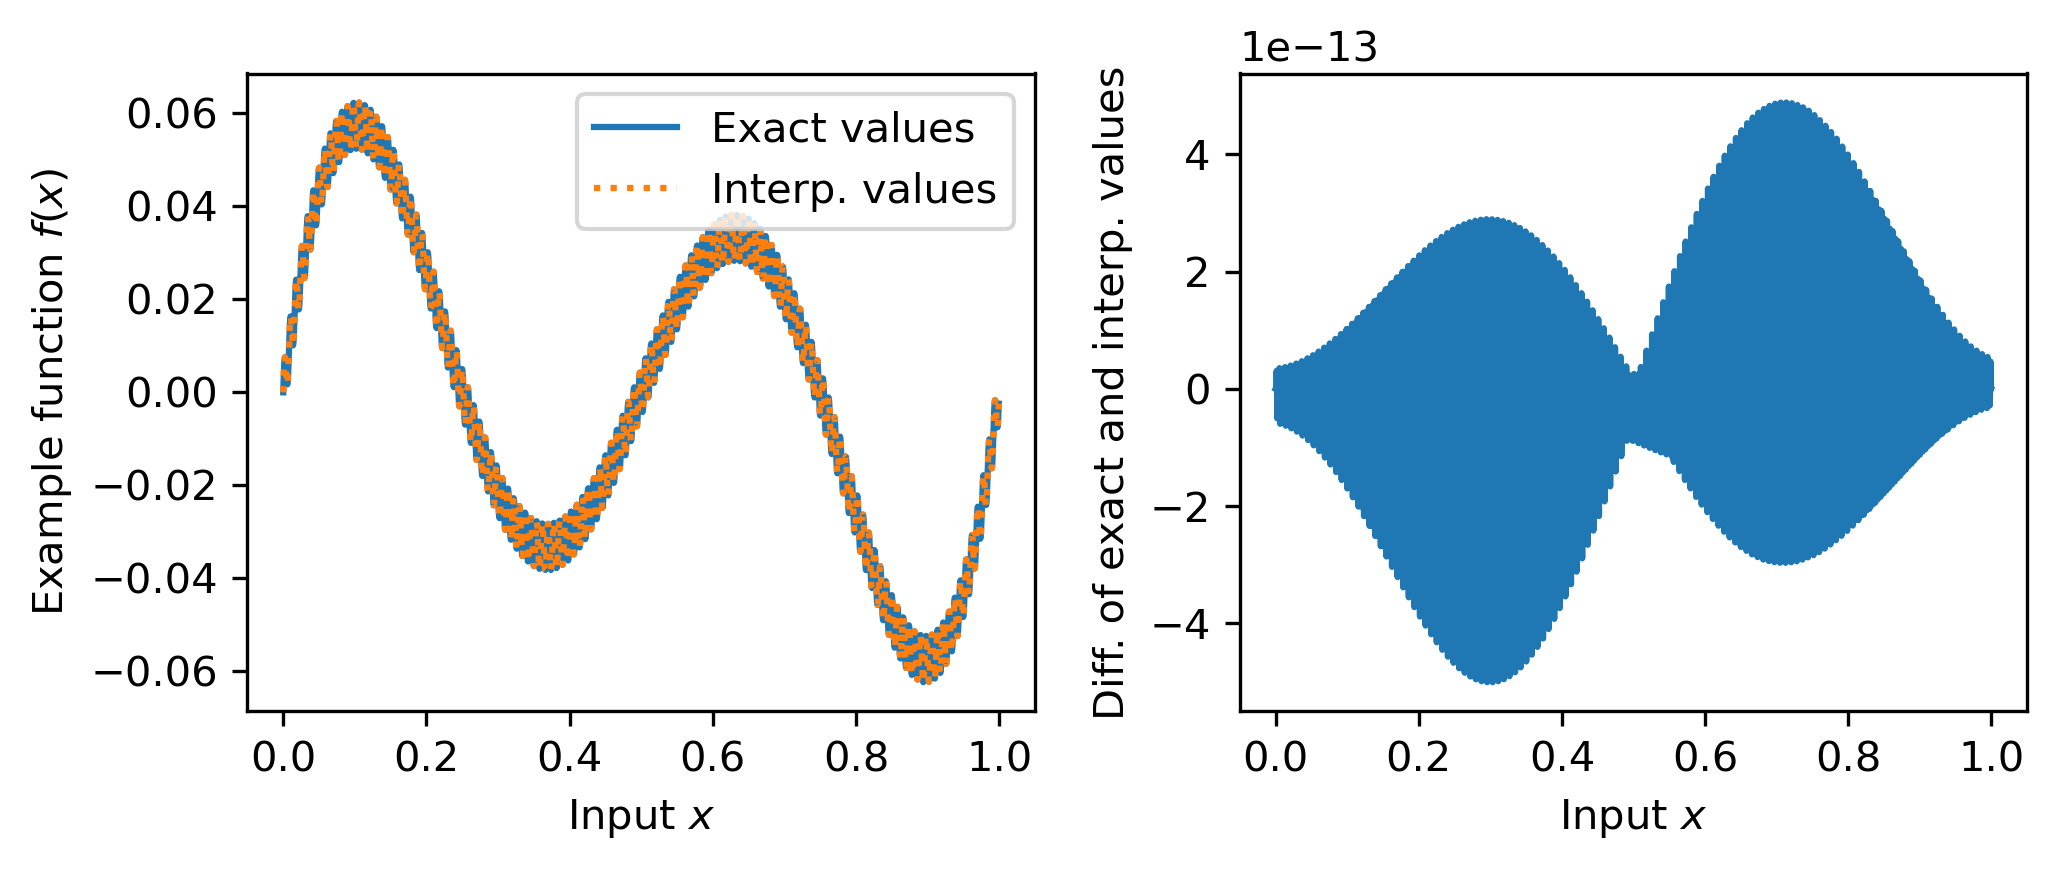

In [37]:
# Create example data, this could be a correlation function
def func(x):
    return np.sin(2*np.pi*x) * (x - 0.25) * (x - 0.75) + 5e-3 * np.sin(250 * np.pi * x)

def tensorized_func(*args):
    L = len(args)
    bits = 2.**np.arange(-1, -L-1, -1)
    x = np.sum(np.array(args) * bits)
    val = func(x)
    return val

# evaluate full function
L = 11
xs = np.arange(2**L) / 2**L
func_vals = func(xs)

# interpolate function
Ms, I, J = tci.tensor_cross_interpolation(tensorized_func,
                                          L=L,
                                          mode='reset',
                                          cache=False,
                                          eps_or_chi=1e-10,
                                          num_sweeps=6)
intp_vals = contract_MPS(Ms)

fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, func_vals, '-', label='Exact values')
axs[0].plot(xs, intp_vals, ':', label='Interp. values')
axs[0].set(xlabel=r'Input $x$',
           ylabel='Example function $f(x)$')
axs[0].legend()

axs[1].plot(xs, func_vals - intp_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and interp. values')

plt.tight_layout()
plt.show()

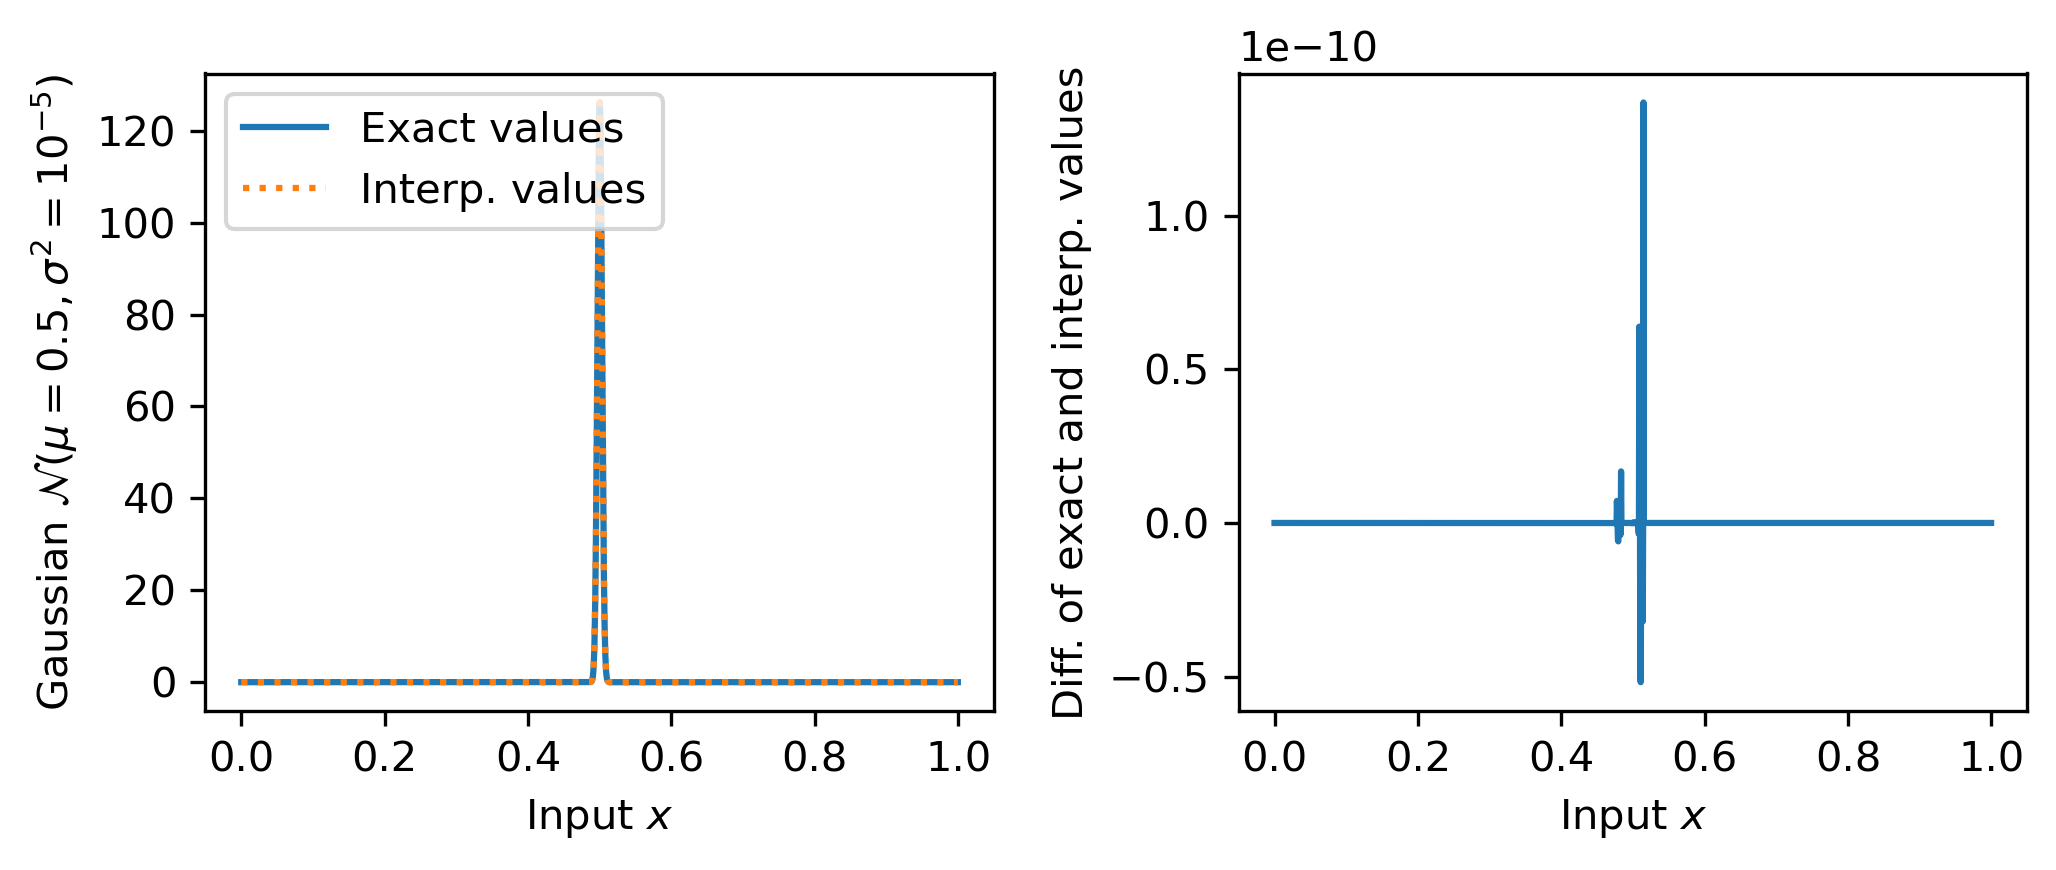

In [38]:
# Create Gaussian windowing function
def Gaussian(x, var=1e-5):
    return np.exp(- (x - 0.5)**2 / (2 * var) ) / np.sqrt(2 * np.pi * var)

def tensorized_Gaussian(*args):
    L = len(args)
    bits = 2.**np.arange(-1, -L-1, -1)
    x = np.sum(np.array(args) * bits)
    val = Gaussian(x)
    return val

# evaluate full function
L =11
xs = np.arange(2**L) / 2**L
Gauss_vals = Gaussian(xs)

#instead of using init_ids = [1]+[0]*(L-1) we use:
init_idxs = []
init_idxs.append([1]+[0]*(L-1))
init_idxs.append([1]+[0]*(L-2)+[1])
init_idxs.append([1]+[0]*(L-3)+[1]+[0])
init_idxs.append([1]+[0]*(L-3)+[1]+[1])
init_idxs.append([0]+[1]*(L-1))
init_idxs.append([0]+[1]*(L-2)+[0])
init_idxs.append([0]+[1]*(L-3)+[0]+[1])
init_idxs.append([0]+[1]*(L-3)+[0]+[0])


# interpolate function (Gaussian is sparse, start the TCI at x=0.5 for stability)
Gs, _, _ = tci.tensor_cross_interpolation(tensorized_Gaussian,
                                          L=L,
                                          mode='reset',
                                          cache=False,
                                          init_idxs=init_idxs,
                                          eps_or_chi=8,
                                          num_sweeps=6)
GMPS_vals = contract_MPS(Gs)

fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, Gauss_vals, '-', label='Exact values')
axs[0].plot(xs, GMPS_vals, ':', label='Interp. values')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Gaussian $\mathcal{N}(\mu=0.5, \sigma^2=10^{-5})$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, Gauss_vals - GMPS_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and interp. values')

plt.tight_layout()
plt.show()

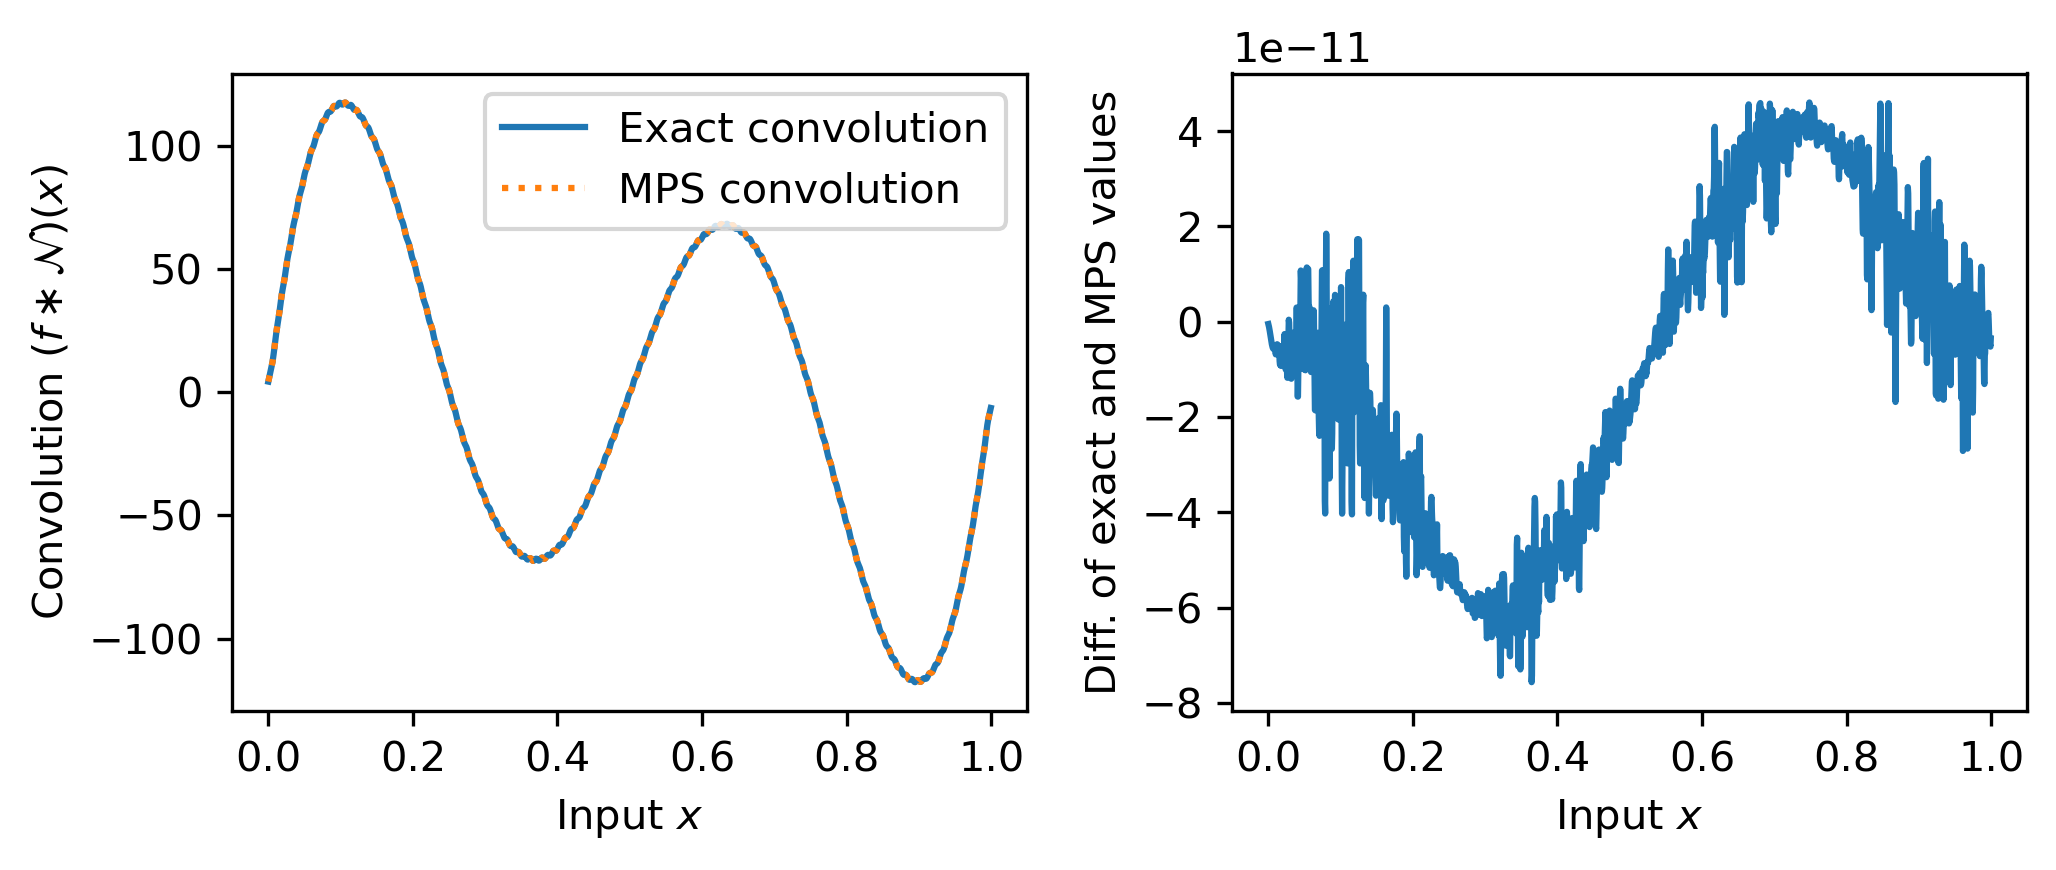

In [39]:
# Implement convolution via MPS
Ws = construct_convolution_MPO(L, conv_MPS=Gs)
conv_Ms = apply_MPO(Ws, Ms)
# in practice one would bring this in canonical form and truncate
# but here we just contract the result to get its values
conv_MPS_vals = contract_MPS(conv_Ms)

# Implement convolution for dense vectors
conv_func_vals = np.convolve(func_vals, Gauss_vals, mode='same')

# plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, conv_func_vals, '-', label='Exact convolution')
axs[0].plot(xs, conv_MPS_vals, ':', label='MPS convolution')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend()

axs[1].plot(xs, conv_func_vals - conv_MPS_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

plt.tight_layout()
plt.show()